In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re

TRN_PTH = "./dl-lab-2-stuff-detection/yolo_dataset/yolo_dataset/train/images"
TST_PTH = "./dl-lab-2-stuff-detection/test_images/test_images"

def plot_bunch(imgs, cols=None, figsize=(15, 5)):
    n = len(imgs)
    if cols is not None:
        rows = n // cols + (n % cols != 0)
    else:
        rows = 1; cols = n
    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    if n == 1: axs = [axs]
    for i, img in enumerate(imgs):
        axs[i].set_title(i)
        axs[i].imshow(img)
        axs[i].axis('off')
    plt.show()

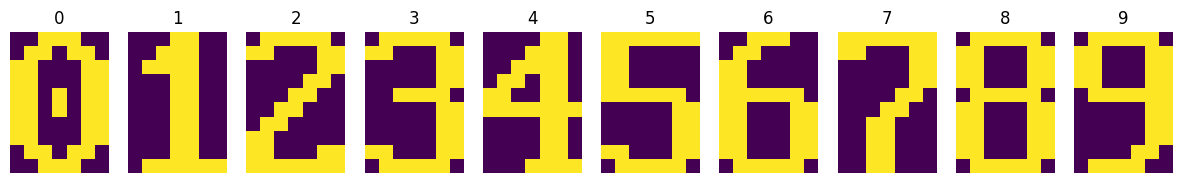

In [11]:
import cv2
import numpy as np

DATETIME_RECT = (0, 16, 342, 32)
NUMS_RECTS = [(xs, 20, 14, 20) for xs in (
    0, 18, 36, 54,  90, 108,  144, 162,
    198, 216,  252, 270,  306, 324
)]

FONT_PATH = './font-filter-weights.bin'
FONT = np.unpackbits(np.fromfile(FONT_PATH, dtype=np.uint8))[:2800].reshape(10, 20, 14)

plot_bunch(FONT)

In [12]:
from turbojpeg import TurboJPEG, TJPF_GRAY

# UNIX: REQUIRE libjpeg-turbo
jpeg = TurboJPEG()
READ_RECT = (0, 0, 342, 48)

def read_crop_fast(img_path):
    with open(img_path, 'rb') as f:
        img_bytes = f.read()
    cropped_jpeg_bytes = jpeg.crop(img_bytes, *READ_RECT)
    crop_img = jpeg.decode(cropped_jpeg_bytes, pixel_format=TJPF_GRAY)
    return crop_img

In [ ]:
# REQUIRE: FONT_PATH

import numpy as np

XS = (0, 18, 36, 54,  90, 108,  144, 162, 198,  216,  252, 270,  306, 324)
Y_IDX = np.arange(20, 40).reshape(1, 20, 1)
X_IDX = np.array(XS).reshape(14, 1, 1) + np.arange(14).reshape(1, 1, 14)
FONT = np.unpackbits(np.fromfile(FONT_PATH, dtype=np.uint8))[:2800].reshape(10, 20, 14)
FONT_BOOL = FONT.astype(bool)

def read_V2(img):
    """ img.shape: (>=48, >=342, 1) \\
        except: TRN-7, TRN-16, TRN-26, TST-8 """
    

    


def get_datetime(img):
    """ except: TRN-7, TRN-16, TRN-26, TST-8 """
    if img.ndim == 3: img = img[:,:,0]
    crops = img[Y_IDX, X_IDX]
    bin_crops = crops > 178
    errors = np.count_nonzero(bin_crops[:, None, :, :] != FONT_BOOL[None, :, :, :], axis=(2, 3))
    best_digits = errors.argmin(axis=1)
    return "".join(best_digits.astype(str))


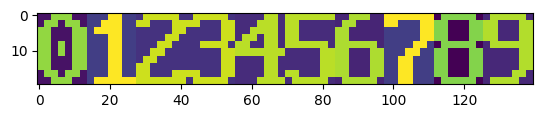

In [ ]:
# REQUIRE: FONT_BOOL, XS

N1 = FONT_BOOL.sum(axis=(1, 2), keepdims=True)
N0 = (~FONT_BOOL).sum(axis=(1, 2), keepdims=True)
W = np.where(FONT_BOOL, 1.0 / N1, -1.0 / N0).astype(np.float32)
# plt.imshow(W.transpose(1, 0, 2).reshape(20, -1));plt.show()
X_IDX2 = np.array(XS).reshape(14, 1, 1) + 1 + np.arange(14).reshape(1, 1, 14)

def get_datetime_v2(img):
    """ for: TRN-7, TRN-16, TRN-26, TST-8 """
    

In [15]:
def datetime_to_fmt(dt: str) -> str:
    # 'YYYYMMDDhhmmss' -> 'YYYY/MM/DD-hh:mm:ss'
    # (0123 45 67) (89 01 23)
    return f"{dt[0:4]}/{dt[4:6]}/{dt[6:8]}-{dt[8:10]}:{dt[10:12]}:{dt[12:14]}"

def datetime_to_datesec(dt: str) -> str:
    # 'YYYYMMDDhhmmss' -> 'YYYY/MM/DD-sssss'
    # (0123 45 67) (89 01 23)
    total_sec = int(dt[8:10])*3600 + int(dt[10:12])*60 + int(dt[12:14])
    return f"{dt[0:4]}/{dt[4:6]}/{dt[6:8]}-{total_sec:05d}"

def fmt_datetime(dt: str) -> tuple[str, str, int]:
    # 'YYYYMMDDhhmmss' -> ('YYYY/MM/DD', 'hh:mm:ss', sssss)
    date = f"{dt[0:4]}/{dt[4:6]}/{dt[6:8]}"
    time_fmt = f"{dt[8:10]}:{dt[10:12]}:{dt[12:14]}"
    time_sec = int(dt[8:10])*3600 + int(dt[10:12])*60 + int(dt[12:14])
    return date, time_fmt, time_sec


dt = "20231105123045"
print(datetime_to_fmt(dt))
print(datetime_to_datesec(dt))
print(fmt_datetime(dt))

2023/11/05-12:30:45
2023/11/05-45045
('2023/11/05', '12:30:45', 45045)


In [57]:
from tqdm import tqdm

_lst = sorted(os.listdir(TRN_PTH))
meta = {}

for fname in tqdm(_lst):
    meta[fname] = fmt_datetime(get_datetime(read_crop_fast(f"{TRN_PTH}/{fname}")))

print(meta)

100%|██████████| 3908/3908 [00:16<00:00, 240.52it/s]

{'0209-10_00864300.jpg': ('2025/09/02', '12:16:33', 44193), '0209-10_00864400.jpg': ('2025/09/02', '12:16:37', 44197), '0209-10_00867700.jpg': ('2025/09/02', '12:18:49', 44329), '0209-10_00867800.jpg': ('2025/09/02', '12:18:53', 44333), '0209-10_00870700.jpg': ('2025/09/02', '12:20:49', 44449), '0209-10_00877400.jpg': ('2025/09/02', '12:25:17', 44717), '0209-10_00877900.jpg': ('2025/09/02', '12:25:37', 44737), '0209-10_00878000.jpg': ('2025/09/02', '12:25:41', 44741), '0209-10_00878100.jpg': ('2025/09/02', '12:25:45', 44745), '0209-10_00878200.jpg': ('2025/09/02', '12:25:49', 44749), '0209-10_00878300.jpg': ('2025/09/02', '12:25:53', 44753), '0209-10_00879200.jpg': ('2025/09/02', '12:26:29', 44789), '0209-10_00883100.jpg': ('2025/09/02', '12:29:05', 44945), '0209-10_00883200.jpg': ('2025/09/02', '12:29:09', 44949), '0209-10_00883300.jpg': ('2025/09/02', '12:29:13', 44953), '0209-10_00890400.jpg': ('2025/09/02', '12:34:13', 45253), '0209-10_00890600.jpg': ('2025/09/02', '12:34:21', 4526

In [ ]:
for k,v in meta.items():
    if k[5:7] == '26':
        print(k, v)

In [ ]:
for k,v in meta.items():
    if v[0].split('/')[0] != '2025':
        print(k, v)

('2025/09/02', '12:26:07', 44767)


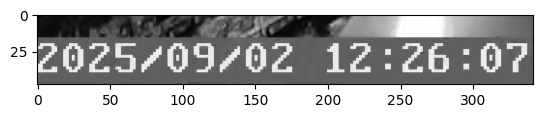

In [20]:
img_path = f"{TRN_PTH}/0209-2_00885400.jpg"
img = read_crop_fast(img_path)
plt.imshow(img, cmap='gray')

# print(get_datetime(img))
print(fmt_datetime(get_datetime(img)))